# DATA425 Lab 10: Seq2Seq, Attention, and Transformers

In this lab, we train a tiny encoder-decoder Transformer on a toy translation task:

$$
\text{English digit words} \rightarrow \text{French digit words}.
$$

Example:

`three five zero` $\rightarrow$ `trois cinq zéro`

The task is intentionally small. That lets you inspect every moving part without being distracted by a large dataset or long training run.

You will work through tokens, vocabularies, special symbols, embeddings, attention weights, masks, self-attention, cross-attention, and autoregressive decoding. These are the same building blocks used in much larger transformer systems.

## Lecture map

This notebook follows the attention and transformer lecture storyline.

| Lecture idea | What you will see in this lab |
|---|---|
| Sequence-to-sequence modelling | source sequence to target sequence translation |
| Tokens | digit words plus `<pad>`, `<bos>`, and `<eos>` |
| One-hot vectors and embeddings | explicit one-hot vectors and learned dense vectors |
| Scaled dot-product attention | a from-scratch implementation of $\operatorname{softmax}(QK^T/\sqrt{d})V$ |
| Queries, keys, and values | attention scores and weighted value vectors |
| Masked self-attention | a causal mask that blocks future target tokens |
| Multi-head attention | PyTorch `MultiheadAttention` with per-head weights |
| Encoder-decoder Transformer | custom encoder and decoder blocks with cross-attention |
| Autoregressive decoding | greedy next-token generation |
| BERT-style and GPT-style objectives | masked-token formatting compared with next-token formatting |

As you work through the lab, keep track of which attention operation is being used: encoder self-attention, decoder masked self-attention, or decoder cross-attention.

In [ ]:
import random
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split


def set_seed(seed=425):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

set_seed(425)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Tokens, vocabularies, and special symbols

A token is a piece of a sequence that the model can process. In this toy task, each token is a whole digit word such as `three` or `sept`.

We also need special tokens:

- `<pad>` fills unused positions so that examples in a batch have the same length,
- `<bos>` marks the beginning of the target sequence for the decoder,
- `<eos>` marks the end of a sequence so decoding can stop.

The vocabulary maps tokens to integer IDs. Neural networks do not process raw strings directly, so every token must be converted to an ID before it can be embedded and passed through the model.

After the next cell, look at the source and target vocabularies. The exact IDs are arbitrary. What matters is that the mapping is consistent.

In [ ]:
src_words = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
tgt_words = ["zéro", "un", "deux", "trois", "quatre", "cinq", "six", "sept", "huit", "neuf"]

SPECIALS = ["<pad>", "<bos>", "<eos>"]
src_vocab = SPECIALS + src_words
tgt_vocab = SPECIALS + tgt_words

src_stoi = {token: idx for idx, token in enumerate(src_vocab)}
tgt_stoi = {token: idx for idx, token in enumerate(tgt_vocab)}
src_itos = {idx: token for token, idx in src_stoi.items()}
tgt_itos = {idx: token for token, idx in tgt_stoi.items()}

PAD = src_stoi["<pad>"]
BOS = tgt_stoi["<bos>"]
EOS = tgt_stoi["<eos>"]

print("Source vocabulary:", src_vocab)
print("Target vocabulary:", tgt_vocab)
print("Vocabulary sizes:", len(src_vocab), len(tgt_vocab))

Source vocabulary: ['<pad>', '<bos>', '<eos>', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
Target vocabulary: ['<pad>', '<bos>', '<eos>', 'zéro', 'un', 'deux', 'trois', 'quatre', 'cinq', 'six', 'sept', 'huit', 'neuf']
Vocabulary sizes: 13 13


## 2. One-hot encoding versus embeddings

A one-hot vector has one dimension for every token in the vocabulary. It is mostly zeros, with a single 1 marking the token ID. This representation tells the model which token is present, but it does not directly express similarity between tokens.

An embedding layer maps token IDs to dense learned vectors. During training, the model adjusts these vectors so they become useful for the task.

The key difference is:

- one-hot vectors are fixed and sparse,
- embeddings are learned and dense.

The next cell shows both representations for a short toy sentence. This makes the input pipeline visible before we move to the transformer.

In [ ]:
toy_sentence = ["one", "two", "three"]
toy_ids = [src_stoi[token] for token in toy_sentence]
one_hot = np.eye(len(src_vocab), dtype=int)[toy_ids]

print("Tokens:", toy_sentence)
print("Token IDs:", toy_ids)
print("One-hot shape:", one_hot.shape)
display(pd.DataFrame(one_hot, index=toy_sentence, columns=src_vocab))

embedding_layer = nn.Embedding(num_embeddings=len(src_vocab), embedding_dim=4)
with torch.no_grad():
    dense_vectors = embedding_layer(torch.tensor(toy_ids)).numpy()

print("Embedding shape:", dense_vectors.shape)
display(pd.DataFrame(dense_vectors, index=toy_sentence, columns=["dim1", "dim2", "dim3", "dim4"]))

Tokens: ['one', 'two', 'three']
Token IDs: [4, 5, 6]
One-hot shape: (3, 13)


,<pad>,<bos>,<eos>,zero,one,two,three,four,five,six,seven,eight,nine
one,0,0,0,0,1,0,0,0,0,0,0,0,0
two,0,0,0,0,0,1,0,0,0,0,0,0,0
three,0,0,0,0,0,0,1,0,0,0,0,0,0


Embedding shape: (3, 4)


,dim1,dim2,dim3,dim4
one,0.392054,0.432711,-0.606065,-0.558558
two,1.241076,-1.646147,1.340972,-1.386156
three,1.673106,-0.034488,-0.069226,-0.475285


## 3. Build a toy sequence-to-sequence translation dataset

Each example is a random sequence of 3 to 6 digit words. The target is the matching French sequence.

During training, the decoder input is shifted right:

$$
[\texttt{<bos>}, y_1, y_2, \ldots, y_{T-1}]
$$

and the target it should predict is:

$$
[y_1, y_2, \ldots, y_T, \texttt{<eos>}].
$$

This is called **teacher forcing**. During training, we give the decoder the true previous target token. This makes training easier because the model learns the next-token task from correct context.

During inference, the true previous target tokens are not available. The model must feed back its own predictions one step at a time.

In [ ]:
rng = np.random.default_rng(425)
pairs = []
for _ in range(2000):
    length = int(rng.integers(3, 7))
    digits = rng.integers(0, 10, size=length).tolist()
    src = [src_words[d] for d in digits]
    tgt = [tgt_words[d] for d in digits]
    pairs.append((src, tgt))

train_pairs, test_pairs = train_test_split(pairs, test_size=0.20, random_state=425)
train_pairs, val_pairs = train_test_split(train_pairs, test_size=0.15, random_state=425)

max_src_len = 7  # max 6 tokens + <eos>
max_tgt_len = 7  # <bos> + max 6 target tokens, and target output has max 6 + <eos>

print("Number of examples:", len(pairs))
print("Train/val/test:", len(train_pairs), len(val_pairs), len(test_pairs))
print("Example pair:")
print("  source:", " ".join(train_pairs[0][0]))
print("  target:", " ".join(train_pairs[0][1]))

Number of examples: 2000
Train/val/test: 1360 240 400
Example pair:
  source: nine one one
  target: neuf un un


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = [src_stoi[w] for w in src] + [src_stoi["<eos>"]]
        tgt_in = [tgt_stoi["<bos>"]] + [tgt_stoi[w] for w in tgt]
        tgt_out = [tgt_stoi[w] for w in tgt] + [tgt_stoi["<eos>"]]

        src_ids = src_ids + [src_stoi["<pad>"]] * (max_src_len - len(src_ids))
        tgt_in = tgt_in + [tgt_stoi["<pad>"]] * (max_tgt_len - len(tgt_in))
        tgt_out = tgt_out + [tgt_stoi["<pad>"]] * (max_tgt_len - len(tgt_out))

        return torch.tensor(src_ids), torch.tensor(tgt_in), torch.tensor(tgt_out)

train_loader = DataLoader(TranslationDataset(train_pairs), batch_size=64, shuffle=True)
val_loader = DataLoader(TranslationDataset(val_pairs), batch_size=128, shuffle=False)
test_loader = DataLoader(TranslationDataset(test_pairs), batch_size=128, shuffle=False)

src_batch, tgt_in_batch, tgt_out_batch = next(iter(train_loader))
print("source batch shape:", tuple(src_batch.shape))
print("target input batch shape:", tuple(tgt_in_batch.shape))
print("target output batch shape:", tuple(tgt_out_batch.shape))
print("\nFirst encoded source example:", src_batch[0].tolist())
print("Decoded:", [src_itos[int(i)] for i in src_batch[0] if int(i) != PAD])

source batch shape: (64, 7)
target input batch shape: (64, 7)
target output batch shape: (64, 7)

First encoded source example: [11, 6, 10, 3, 9, 2, 0]
Decoded: ['eight', 'three', 'seven', 'zero', 'six', '<eos>']


## 4. Scaled dot-product attention from scratch

Attention lets one position decide which other positions are relevant.

The scaled dot-product attention formula is:

$$
\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V.
$$

The roles are:

- **queries $Q$:** what the current position is looking for,
- **keys $K$:** what each available position offers for matching,
- **values $V$:** the information to combine after the weights are chosen.

The dot products $QK^T$ produce relevance scores. The softmax turns those scores into attention weights that sum to 1. Multiplying by $V$ gives a weighted average of value vectors.

The division by $\sqrt{d_k}$ keeps the scores from becoming too large when the vector dimension is large.

Q shape: (3, 4) K shape: (3, 4) V shape: (3, 4)
Attention-weight matrix shape: (3, 3)
Each row sums to: [1.        0.9999999 1.       ]


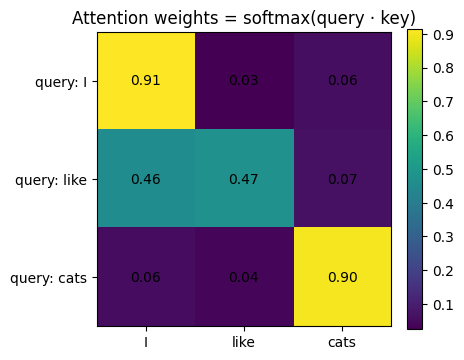

In [ ]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    context = weights @ V
    return context, weights, scores

# Tiny deterministic example: 3 token vectors, one query per token.
torch.manual_seed(425)
X_demo = torch.randn(3, 4)
Wq = torch.randn(4, 4)
Wk = torch.randn(4, 4)
Wv = torch.randn(4, 4)
Q = X_demo @ Wq
K = X_demo @ Wk
V = X_demo @ Wv
context, weights, scores = scaled_dot_product_attention(Q, K, V)

print("Q shape:", tuple(Q.shape), "K shape:", tuple(K.shape), "V shape:", tuple(V.shape))
print("Attention-weight matrix shape:", tuple(weights.shape))
print("Each row sums to:", weights.sum(dim=-1).detach().numpy())

tokens = ["I", "like", "cats"]
fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(weights.detach().numpy())
ax.set_xticks(range(3)); ax.set_xticklabels(tokens)
ax.set_yticks(range(3)); ax.set_yticklabels([f"query: {t}" for t in tokens])
ax.set_title("Attention weights = softmax(query · key)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{weights[i, j]:.2f}", ha="center", va="center")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 5. Causal masking for decoder self-attention

During autoregressive generation, the decoder predicts the next token using only previous tokens. It must not see future target tokens.

A causal mask blocks attention from position $i$ to future positions $j > i$. In other words, token 3 can attend to tokens 1, 2, and 3, but not token 4.

This is essential for fair next-token training. Without the mask, the model could cheat by looking at the answer it is supposed to predict.

The next cell builds and visualizes the mask. Read the printed matrix as a rule about which positions are hidden from each query position.

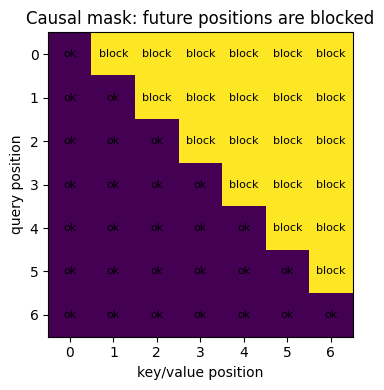

In [ ]:
def make_causal_mask(T, device="cpu"):
    # True means "masked out" for PyTorch MultiheadAttention.
    return torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), diagonal=1)

mask = make_causal_mask(7).cpu().numpy()
plt.figure(figsize=(4.5, 4))
plt.imshow(mask)
plt.title("Causal mask: future positions are blocked")
plt.xlabel("key/value position")
plt.ylabel("query position")
plt.xticks(range(7))
plt.yticks(range(7))
for i in range(7):
    for j in range(7):
        plt.text(j, i, "block" if mask[i, j] else "ok", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 6. Build a tiny encoder-decoder Transformer

The model has these parts:

1. source token embeddings plus position embeddings,
2. encoder self-attention,
3. source feed-forward layers,
4. target token embeddings plus position embeddings,
5. decoder masked self-attention,
6. decoder cross-attention over encoder outputs,
7. decoder feed-forward layers,
8. a final vocabulary projection.

The three attention roles are different:

- **encoder self-attention:** source tokens look at other source tokens,
- **decoder masked self-attention:** target tokens look at earlier target tokens,
- **decoder cross-attention:** target tokens look back at source-token representations.

Cross-attention is what lets the decoder use the input sequence while generating the output sequence.

In [ ]:
class PositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, padding_idx=0):
        super().__init__()
        self.token = nn.Embedding(vocab_size, d_model, padding_idx=padding_idx)
        self.position = nn.Embedding(max_len, d_model)
        self.scale = math.sqrt(d_model)

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        return self.token(x) * self.scale + self.position(positions)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dim_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=src_key_padding_mask, need_weights=False)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x

class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dim_ff=128, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None, tgt_key_padding_mask=None, src_key_padding_mask=None):
        self_out, _ = self.self_attn(
            x, x, x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False,
        )
        x = self.norm1(x + self.dropout(self_out))
        cross_out, cross_weights = self.cross_attn(
            x, memory, memory,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False,
        )
        x = self.norm2(x + self.dropout(cross_out))
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x, cross_weights

class TinyTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, n_heads=4, num_layers=1):
        super().__init__()
        self.src_embedding = PositionalEmbedding(src_vocab_size, d_model, max_src_len)
        self.tgt_embedding = PositionalEmbedding(tgt_vocab_size, d_model, max_tgt_len)
        self.encoders = nn.ModuleList([EncoderBlock(d_model, n_heads) for _ in range(num_layers)])
        self.decoders = nn.ModuleList([DecoderBlock(d_model, n_heads) for _ in range(num_layers)])
        self.output = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt_in):
        src_padding = (src == PAD)
        tgt_padding = (tgt_in == PAD)

        memory = self.src_embedding(src)
        for encoder in self.encoders:
            memory = encoder(memory, src_key_padding_mask=src_padding)

        x = self.tgt_embedding(tgt_in)
        tgt_mask = make_causal_mask(tgt_in.size(1), device=tgt_in.device)
        cross_weights = None
        for decoder in self.decoders:
            x, cross_weights = decoder(
                x, memory,
                tgt_mask=tgt_mask,
                tgt_key_padding_mask=tgt_padding,
                src_key_padding_mask=src_padding,
            )
        logits = self.output(x)
        return logits, cross_weights

model = TinyTransformer(len(src_vocab), len(tgt_vocab), d_model=64, n_heads=4, num_layers=1).to(device)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

with torch.no_grad():
    logits, cross_weights = model(src_batch[:2].to(device), tgt_in_batch[:2].to(device))
print("Logits shape:", tuple(logits.shape), "= (batch, target positions, target vocabulary size)")
print("Cross-attention weights shape:", tuple(cross_weights.shape), "= (batch, heads, target positions, source positions)")

TinyTransformer(
  (src_embedding): PositionalEmbedding(
    (token): Embedding(13, 64, padding_idx=0)
    (position): Embedding(7, 64)
  )
  (tgt_embedding): PositionalEmbedding(
    (token): Embedding(13, 64, padding_idx=0)
    (position): Embedding(7, 64)
  )
  (encoders): ModuleList(
    (0): EncoderBlock(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=64, out_features=128, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (decoders): ModuleList(
    (0): DecoderBlock(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuant

Logits shape: (2, 7, 13) = (batch, target positions, target vocabulary size)
Cross-attention weights shape: (2, 4, 7, 7) = (batch, heads, target positions, source positions)


## 7. Train the Transformer

At each decoder position, the model predicts a distribution over the target vocabulary. Cross-entropy loss compares that distribution with the correct next token.

We ignore `<pad>` targets in the loss because padding is not real sequence content. Token-level accuracy is also computed only on non-padding positions.

A low loss means the model is placing more probability on the correct target tokens. A high token accuracy means the most likely token is often correct. Both metrics are useful, but they are not identical.

The training curve should improve quickly because the task is small and highly structured.

In [ ]:
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)


def evaluate_translation(model, loader):
    model.eval()
    total_loss, total_examples = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            logits, _ = model(src, tgt_in)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item() * src.size(0)
            total_examples += src.size(0)
            pred = logits.argmax(dim=-1)
            mask = tgt_out != PAD
            correct_tokens += (pred[mask] == tgt_out[mask]).sum().item()
            total_tokens += mask.sum().item()
    return total_loss / total_examples, correct_tokens / total_tokens

history = []
for epoch in range(1, 21):
    model.train()
    total_loss, total_examples = 0.0, 0
    for src, tgt_in, tgt_out in train_loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        optimizer.zero_grad()
        logits, _ = model(src, tgt_in)
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * src.size(0)
        total_examples += src.size(0)
    val_loss, val_token_acc = evaluate_translation(model, val_loader)
    history.append({"epoch": epoch, "train_loss": total_loss / total_examples, "val_loss": val_loss, "val_token_acc": val_token_acc})
    if epoch in {1, 2, 5, 10, 15, 20}:
        row = history[-1]
        print(f"epoch {epoch:02d} | train loss {row['train_loss']:.3f} | val loss {row['val_loss']:.3f} | val token acc {row['val_token_acc']:.3f}")

history = pd.DataFrame(history)
test_loss, test_token_acc = evaluate_translation(model, test_loader)
print(f"\nHeld-out test token accuracy: {test_token_acc:.3f}")

epoch 01 | train loss 2.005 | val loss 1.523 | val token acc 0.393


epoch 02 | train loss 1.400 | val loss 1.055 | val token acc 0.589


epoch 05 | train loss 0.785 | val loss 0.628 | val token acc 0.751


epoch 10 | train loss 0.081 | val loss 0.033 | val token acc 0.987


epoch 15 | train loss 0.018 | val loss 0.016 | val token acc 0.997


epoch 20 | train loss 0.008 | val loss 0.001 | val token acc 1.000

Held-out test token accuracy: 1.000


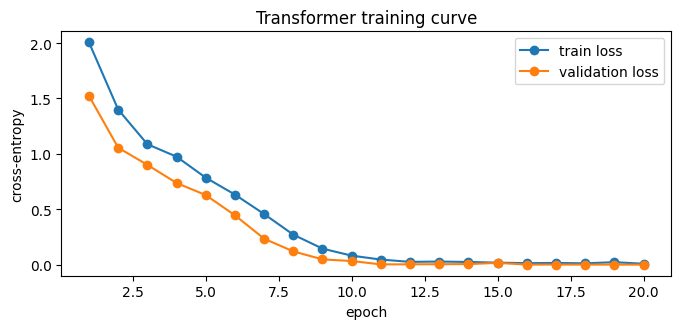

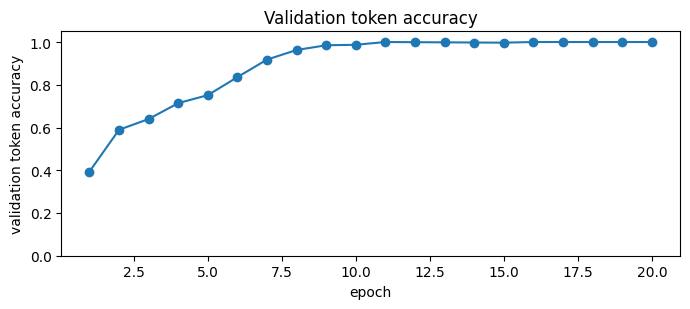

In [ ]:
plt.figure(figsize=(7, 3.4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")
plt.plot(history["epoch"], history["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Transformer training curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.2))
plt.plot(history["epoch"], history["val_token_acc"], marker="o")
plt.ylim(0, 1.05)
plt.xlabel("epoch")
plt.ylabel("validation token accuracy")
plt.title("Validation token accuracy")
plt.tight_layout()
plt.show()

## 8. Autoregressive decoding

During inference, the decoder does not receive the true target sequence. It starts with `<bos>` and then repeats this loop:

1. predict the next token,
2. append that predicted token to the decoder input,
3. predict the next token again,
4. stop when `<eos>` is produced or when the maximum length is reached.

This is autoregressive decoding. It is GPT-like because generation happens one token at a time from previous tokens. In this encoder-decoder model, generation is also conditioned on the encoded source sequence.

The decoding function below uses greedy decoding, which always chooses the most likely next token. Greedy decoding is simple and useful for this toy task.

In [ ]:
def encode_source(src_tokens):
    ids = [src_stoi[w] for w in src_tokens] + [src_stoi["<eos>"]]
    ids = ids + [src_stoi["<pad>"]] * (max_src_len - len(ids))
    return torch.tensor([ids], dtype=torch.long, device=device)

@torch.no_grad()
def translate(src_tokens, max_steps=8):
    model.eval()
    src = encode_source(src_tokens)
    generated = [BOS]
    last_weights = None
    for _ in range(max_steps):
        tgt_in = generated + [PAD] * (max_tgt_len - len(generated))
        tgt_in = torch.tensor([tgt_in[:max_tgt_len]], dtype=torch.long, device=device)
        logits, last_weights = model(src, tgt_in)
        next_position = len(generated) - 1
        next_id = int(logits[0, next_position].argmax().item())
        if next_id == EOS or len(generated) >= max_tgt_len:
            break
        generated.append(next_id)
    return [tgt_itos[i] for i in generated[1:]], last_weights

for src, tgt in test_pairs[:10]:
    pred, _ = translate(src)
    print(f"{' '.join(src):35s} -> {' '.join(pred):35s} | target: {' '.join(tgt)}")

three five six zero eight five      -> trois cinq six zéro huit cinq       | target: trois cinq six zéro huit cinq
nine zero two seven zero            -> neuf zéro deux sept zéro            | target: neuf zéro deux sept zéro
four nine nine nine three           -> quatre neuf neuf neuf trois         | target: quatre neuf neuf neuf trois
four two seven two two one          -> quatre deux sept deux deux un       | target: quatre deux sept deux deux un
eight two eight                     -> huit deux huit                      | target: huit deux huit
seven zero three                    -> sept zéro trois                     | target: sept zéro trois
two nine four                       -> deux neuf quatre                    | target: deux neuf quatre
seven zero eight six                -> sept zéro huit six                  | target: sept zéro huit six
five five zero                      -> cinq cinq zéro                      | target: cinq cinq zéro
four three two eight                -> q

## 9. Inspect learned cross-attention weights

Cross-attention connects target positions to source positions.

In the heatmap:

- each row corresponds to one target token being generated,
- each column corresponds to one source token,
- each row sums to 1 across the source positions.

For this digit translation task, the alignment is usually simple: the French word for a digit often attends most strongly to the matching English digit word.

The attention plot is not just decoration. It helps you inspect what information the decoder used when producing each output token.

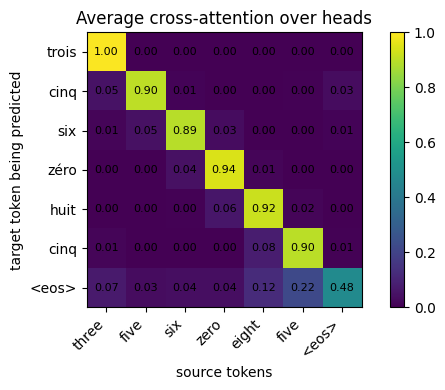

Source: three five six zero eight five
Target: trois cinq six zéro huit cinq
Raw cross-attention tensor shape: batch × heads × target positions × source positions


In [ ]:
@torch.no_grad()
def cross_attention_for_pair(src_tokens, tgt_tokens):
    model.eval()
    src_ids = [src_stoi[w] for w in src_tokens] + [src_stoi["<eos>"]]
    tgt_in = [tgt_stoi["<bos>"]] + [tgt_stoi[w] for w in tgt_tokens]
    src_ids = src_ids + [src_stoi["<pad>"]] * (max_src_len - len(src_ids))
    tgt_in = tgt_in + [tgt_stoi["<pad>"]] * (max_tgt_len - len(tgt_in))
    src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)
    tgt_tensor = torch.tensor([tgt_in], dtype=torch.long, device=device)
    logits, weights = model(src_tensor, tgt_tensor)
    # weights: batch × heads × target positions × source positions
    avg_weights = weights.mean(dim=1)[0].cpu().numpy()
    return avg_weights

sample_src, sample_tgt = test_pairs[0]
weights = cross_attention_for_pair(sample_src, sample_tgt)
row_labels = sample_tgt + ["<eos>"]
col_labels = sample_src + ["<eos>"]
heat = weights[:len(row_labels), :len(col_labels)]

fig, ax = plt.subplots(figsize=(max(5, len(col_labels) * 0.9), max(4, len(row_labels) * 0.55)))
im = ax.imshow(heat, vmin=0, vmax=1)
ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels)
ax.set_xlabel("source tokens")
ax.set_ylabel("target token being predicted")
ax.set_title("Average cross-attention over heads")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print("Source:", " ".join(sample_src))
print("Target:", " ".join(sample_tgt))
print("Raw cross-attention tensor shape: batch × heads × target positions × source positions")

## 10. BERT-style masked-token training versus GPT-style next-token training

Transformers can be trained with different objectives. Two common formats are masked-token prediction and next-token prediction.

This cell does not train BERT or GPT. It only shows the data formatting difference.

**BERT-style masked-token format:** hide one token and predict it using both left and right context.

Example idea:

$$
\text{the cat [MASK] on the mat} \rightarrow \text{sat}.
$$

**GPT-style next-token format:** predict the next token using only previous tokens.

Example idea:

$$
\text{the cat sat} \rightarrow \text{on}.
$$

The architecture and mask must match the objective. A bidirectional encoder can use both sides of the context. An autoregressive decoder must preserve the left-to-right prediction rule.

In [ ]:
sentence = ["the", "cat", "sat", "on", "the", "mat"]
masked_position = 2
bert_input = sentence.copy()
bert_target = bert_input[masked_position]
bert_input[masked_position] = "<mask>"

print("BERT-style masked-token example")
print(" input: ", " ".join(bert_input))
print(" target:", bert_target)

print("\nGPT-style next-token examples")
for i in range(1, len(sentence)):
    context = sentence[:i]
    target = sentence[i]
    print(f" input: {' '.join(context):20s} -> target: {target}")

BERT-style masked-token example
 input:  the cat <mask> on the mat
 target: sat

GPT-style next-token examples
 input: the                  -> target: cat
 input: the cat              -> target: sat
 input: the cat sat          -> target: on
 input: the cat sat on       -> target: the
 input: the cat sat on the   -> target: mat


## Lab takeaways

Sequence-to-sequence models map an input sequence to an output sequence. Older RNN encoder-decoder models compress the source into a fixed-size vector, which can become a bottleneck for long inputs. Attention keeps source representations available and lets the decoder choose what to look at for each output position.

Transformers build the whole architecture around attention. Encoder self-attention builds contextual source representations. Decoder masked self-attention preserves the left-to-right generation rule. Decoder cross-attention connects generated target tokens back to the source sequence.

### Suggested extensions

1. Reverse the target order and retrain. Does attention become less diagonal?
2. Add repeated tokens and inspect whether attention distinguishes identical source words.
3. Increase the number of encoder or decoder layers from 1 to 2.
4. Remove the causal mask and explain why the setup becomes invalid for autoregressive decoding.
5. Replace greedy decoding with beam search and compare generated sequences.